# Exercise 5: Music Classification and Statistical Testing

## Imports

In [28]:
import pathlib
from typing import Dict

import arff
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split


from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Constants

In [29]:
current_dir = pathlib.Path.cwd()

# Data path
data_dir_path = current_dir.joinpath("data")
train_arff_file = data_dir_path.joinpath("PopRock-TS120-FP1.arff")
test_arff_file = data_dir_path.joinpath("PopRock-TAS120-FP1.arff")

N_DECISION_TREES = 10

SEED = 0

## E1: Genre Classification with Decision Trees

In this exercise, you will train decision trees for binary genre classification between pop and rock mu-
sic. For this, you can use the sklearn implementation of sklearn.DecisionTreeClassifier.
Use the features and labels contained in the files PopRock-TS120-FP1.arff as training set, and
PopRock-TAS120-FP1.arff as test set. Note that the final category in the arff files is the label
indicator, where AG Pop corresponds to pop music, and NOT AG Pop corresponds to rock music.
Conduct the following experiment: Create 10 decision trees with 10% of the training set, randomly
chosen each time. Then, create 10 more decision trees using 50% of the training data.
Use the test set to measure the difference between the mean precision, recall and F1-scores of trees
created with more and less data.

In [30]:
def load_df(arff_file_path: pathlib.Path) -> pd.DataFrame:
    with open(arff_file_path, 'r') as f:
        print(f"Loading data from {arff_file_path}")
        dataset = arff.load(f)
        columns = [attr[0] for attr in dataset['attributes']]
        df = pd.DataFrame(dataset['data'], columns=columns)
        return df


train_df = load_df(train_arff_file)
test_df = load_df(test_arff_file)
print(train_df.head())
print(test_df.head())

target_column = train_df.columns[-1]

test_features = test_df.drop(columns=[target_column])
test_labels = test_df[target_column]

Loading data from /home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e5/data/PopRock-TS120-FP1.arff
Loading data from /home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e5/data/PopRock-TAS120-FP1.arff
   Mean_1(Normalized(NaN_eliminated(Zero-crossing rate)))  \
0                                           0.099468        
1                                           0.087151        
2                                           0.184871        
3                                           0.142765        
4                                           0.144051        

   Mean_1(Normalized(NaN_eliminated(Root mean square)))  \
0                                           0.363160      
1                                           0.449483      
2                                           0.416395      
3                                           0.505924      
4                                           0.264528      

   Mean_1(Normalized(NaN_eliminated(Low ene

In [31]:
# 10 trees with 10% of the training set (randomly chosen)

def get_model_name(seed: int, train_size: float) -> str:
    return f"{int(train_size * 100)}_{seed}"


def get_decision_trees(train_df: pd.DataFrame, n: int = N_DECISION_TREES, seed: int = SEED, train_size: float = 0.1) -> \
        Dict[int, tree.DecisionTreeClassifier]:
    assert 0.0 <= train_size <= 1.0, f"train_size must be between 0.0 and 1.0, but is {train_size}"

    trees_dict = {}
    for seed in np.arange(seed, seed + n):
        # Split data randomly
        train_10, rest_90 = train_test_split(train_df, test_size=1 - train_size, random_state=seed)

        # Extract features and labels
        X = train_10.drop(columns=[target_column])
        Y = train_10[target_column]

        # Create a decision tree & train
        clf = tree.DecisionTreeClassifier()
        clf = clf.fit(X, Y)

        trees_dict[get_model_name(seed, train_size)] = clf

    return trees_dict

In [32]:
trees10_dict = get_decision_trees(train_df, n=N_DECISION_TREES, train_size=0.1)
trees50_dict = get_decision_trees(train_df, n=N_DECISION_TREES, train_size=0.5)
all_trees_dict = trees10_dict | trees50_dict

In [33]:
def evaluate_models(trees_dict: Dict[str, tree.DecisionTreeClassifier]) -> pd.DataFrame:
    results = []

    for model_name, clf in trees_dict.items():
        # Inference
        predicted_labels = clf.predict(test_features)

        # Calculate precision, recall and F1-score
        results.append({
            "model_name": model_name,
            "precision": (precision_score(test_labels, predicted_labels, average='weighted')),
            "recall": (recall_score(test_labels, predicted_labels, average='weighted')),
            "f1_score": (f1_score(test_labels, predicted_labels, average='weighted'))
        })

    return pd.DataFrame(results)


results_df = evaluate_models(all_trees_dict)
print(results_df)

   model_name  precision    recall  f1_score
0        10_0   0.644257  0.650000  0.646406
1        10_1   0.643056  0.658333  0.639697
2        10_2   0.539583  0.508333  0.516138
3        10_3   0.585276  0.616667  0.579172
4        10_4   0.535387  0.508333  0.516034
5        10_5   0.734375  0.625000  0.620435
6        10_6   0.627622  0.583333  0.589161
7        10_7   0.555761  0.608333  0.538978
8        10_8   0.692445  0.700000  0.692961
9        10_9   0.588443  0.625000  0.558596
10       50_0   0.644257  0.650000  0.646406
11       50_1   0.712488  0.716667  0.713757
12       50_2   0.737500  0.741667  0.738235
13       50_3   0.641878  0.658333  0.631823
14       50_4   0.746604  0.750000  0.747433
15       50_5   0.650000  0.650000  0.650000
16       50_6   0.709680  0.708333  0.708957
17       50_7   0.593122  0.616667  0.593699
18       50_8   0.714361  0.716667  0.715311
19       50_9   0.697523  0.700000  0.698565


## E2: Statistical Testing

Test whether the precision, recall and F1-scores of your decision trees are normally distributed. Then,
use non-parametric statistical testing to see if the differences in performance are statistically signifi-
cant (α= 0.05).

In [40]:

metrics = ["precision", "recall", "f1_score"]

#filter out dataframes for which used either 10 or 50 percent of the training dataset
df_10 = results_df[results_df["model_name"].str.startswith("10")]
df_50 = results_df[results_df["model_name"].str.startswith("50")]

alpha = 0.05

for metric in metrics:
    print(f"\n Analysis for: {metric.upper()}")


    data_10 = df_10[metric]
    data_50 = df_50[metric]
    
    # test if its a normaldistribution
    shapiro_10 = stats.shapiro(data_10)
    shapiro_50 = stats.shapiro(data_50)
    
    #print out p values
    print("Shapiro-Wilk p-values:")
    print(f"p-value (10%): {shapiro_10.pvalue:.4f}")
    print(f"p-value (50%): {shapiro_50.pvalue:.4f}")
    

    #see if p is smaller than alpha in either distriibution 
    if shapiro_10.pvalue < alpha or shapiro_50.pvalue < alpha:
        print("At least one distribution is not a normal distribution")
    else:
        print("Both distributions are normal distributions")


    # non parametric significancy test
    u_stat, p_val = stats.mannwhitneyu(data_10, data_50, alternative="two-sided")
    
    print(f"Mann-Whitney-U p-value: {p_val:.4f}")
    
    if p_val < alpha:
        print(f"Difference is significant (p < {alpha}).")
    else:
        print(f"Difference is not significant")


 Analysis for: PRECISION
Shapiro-Wilk p-values:
p-value (10%): 0.5741
p-value (50%): 0.3616
Both distributions are normal distributions
Mann-Whitney-U p-value: 0.0155
Difference is significant (p < 0.05).

 Analysis for: RECALL
Shapiro-Wilk p-values:
p-value (10%): 0.3083
p-value (50%): 0.4670
Both distributions are normal distributions
Mann-Whitney-U p-value: 0.0050
Difference is significant (p < 0.05).

 Analysis for: F1_SCORE
Shapiro-Wilk p-values:
p-value (10%): 0.6814
p-value (50%): 0.4019
Both distributions are normal distributions
Mann-Whitney-U p-value: 0.0025
Difference is significant (p < 0.05).


In [ ]:

# TODO add plots


## E3: Feature Evaluation

Visualise one of your trees for the low-data case and one for the large-data case, using the tutorial
given by sklearn.
Finally, investigate the features your decision trees have chosen to classify the data. Which features
are chosen most commonly?

Top 5 most common features
Mean_1(Normalized(NaN_eliminated(Consonance - NNLS)))                       0.194061
Mean_13(Normalized(NaN_eliminated(Mel frequency cepstral coefficients)))    0.106349
Mean_12(Normalized(NaN_eliminated(Mel frequency cepstral coefficients)))    0.091889
Mean_6(Normalized(NaN_eliminated(Mel frequency cepstral coefficients)))     0.089052
Mean_4(Normalized(NaN_eliminated(Mel frequency cepstral coefficients)))     0.066286
Name: mean_importance, dtype: float64


Text(0.5, 0, 'middle feature importance / Gini importance')

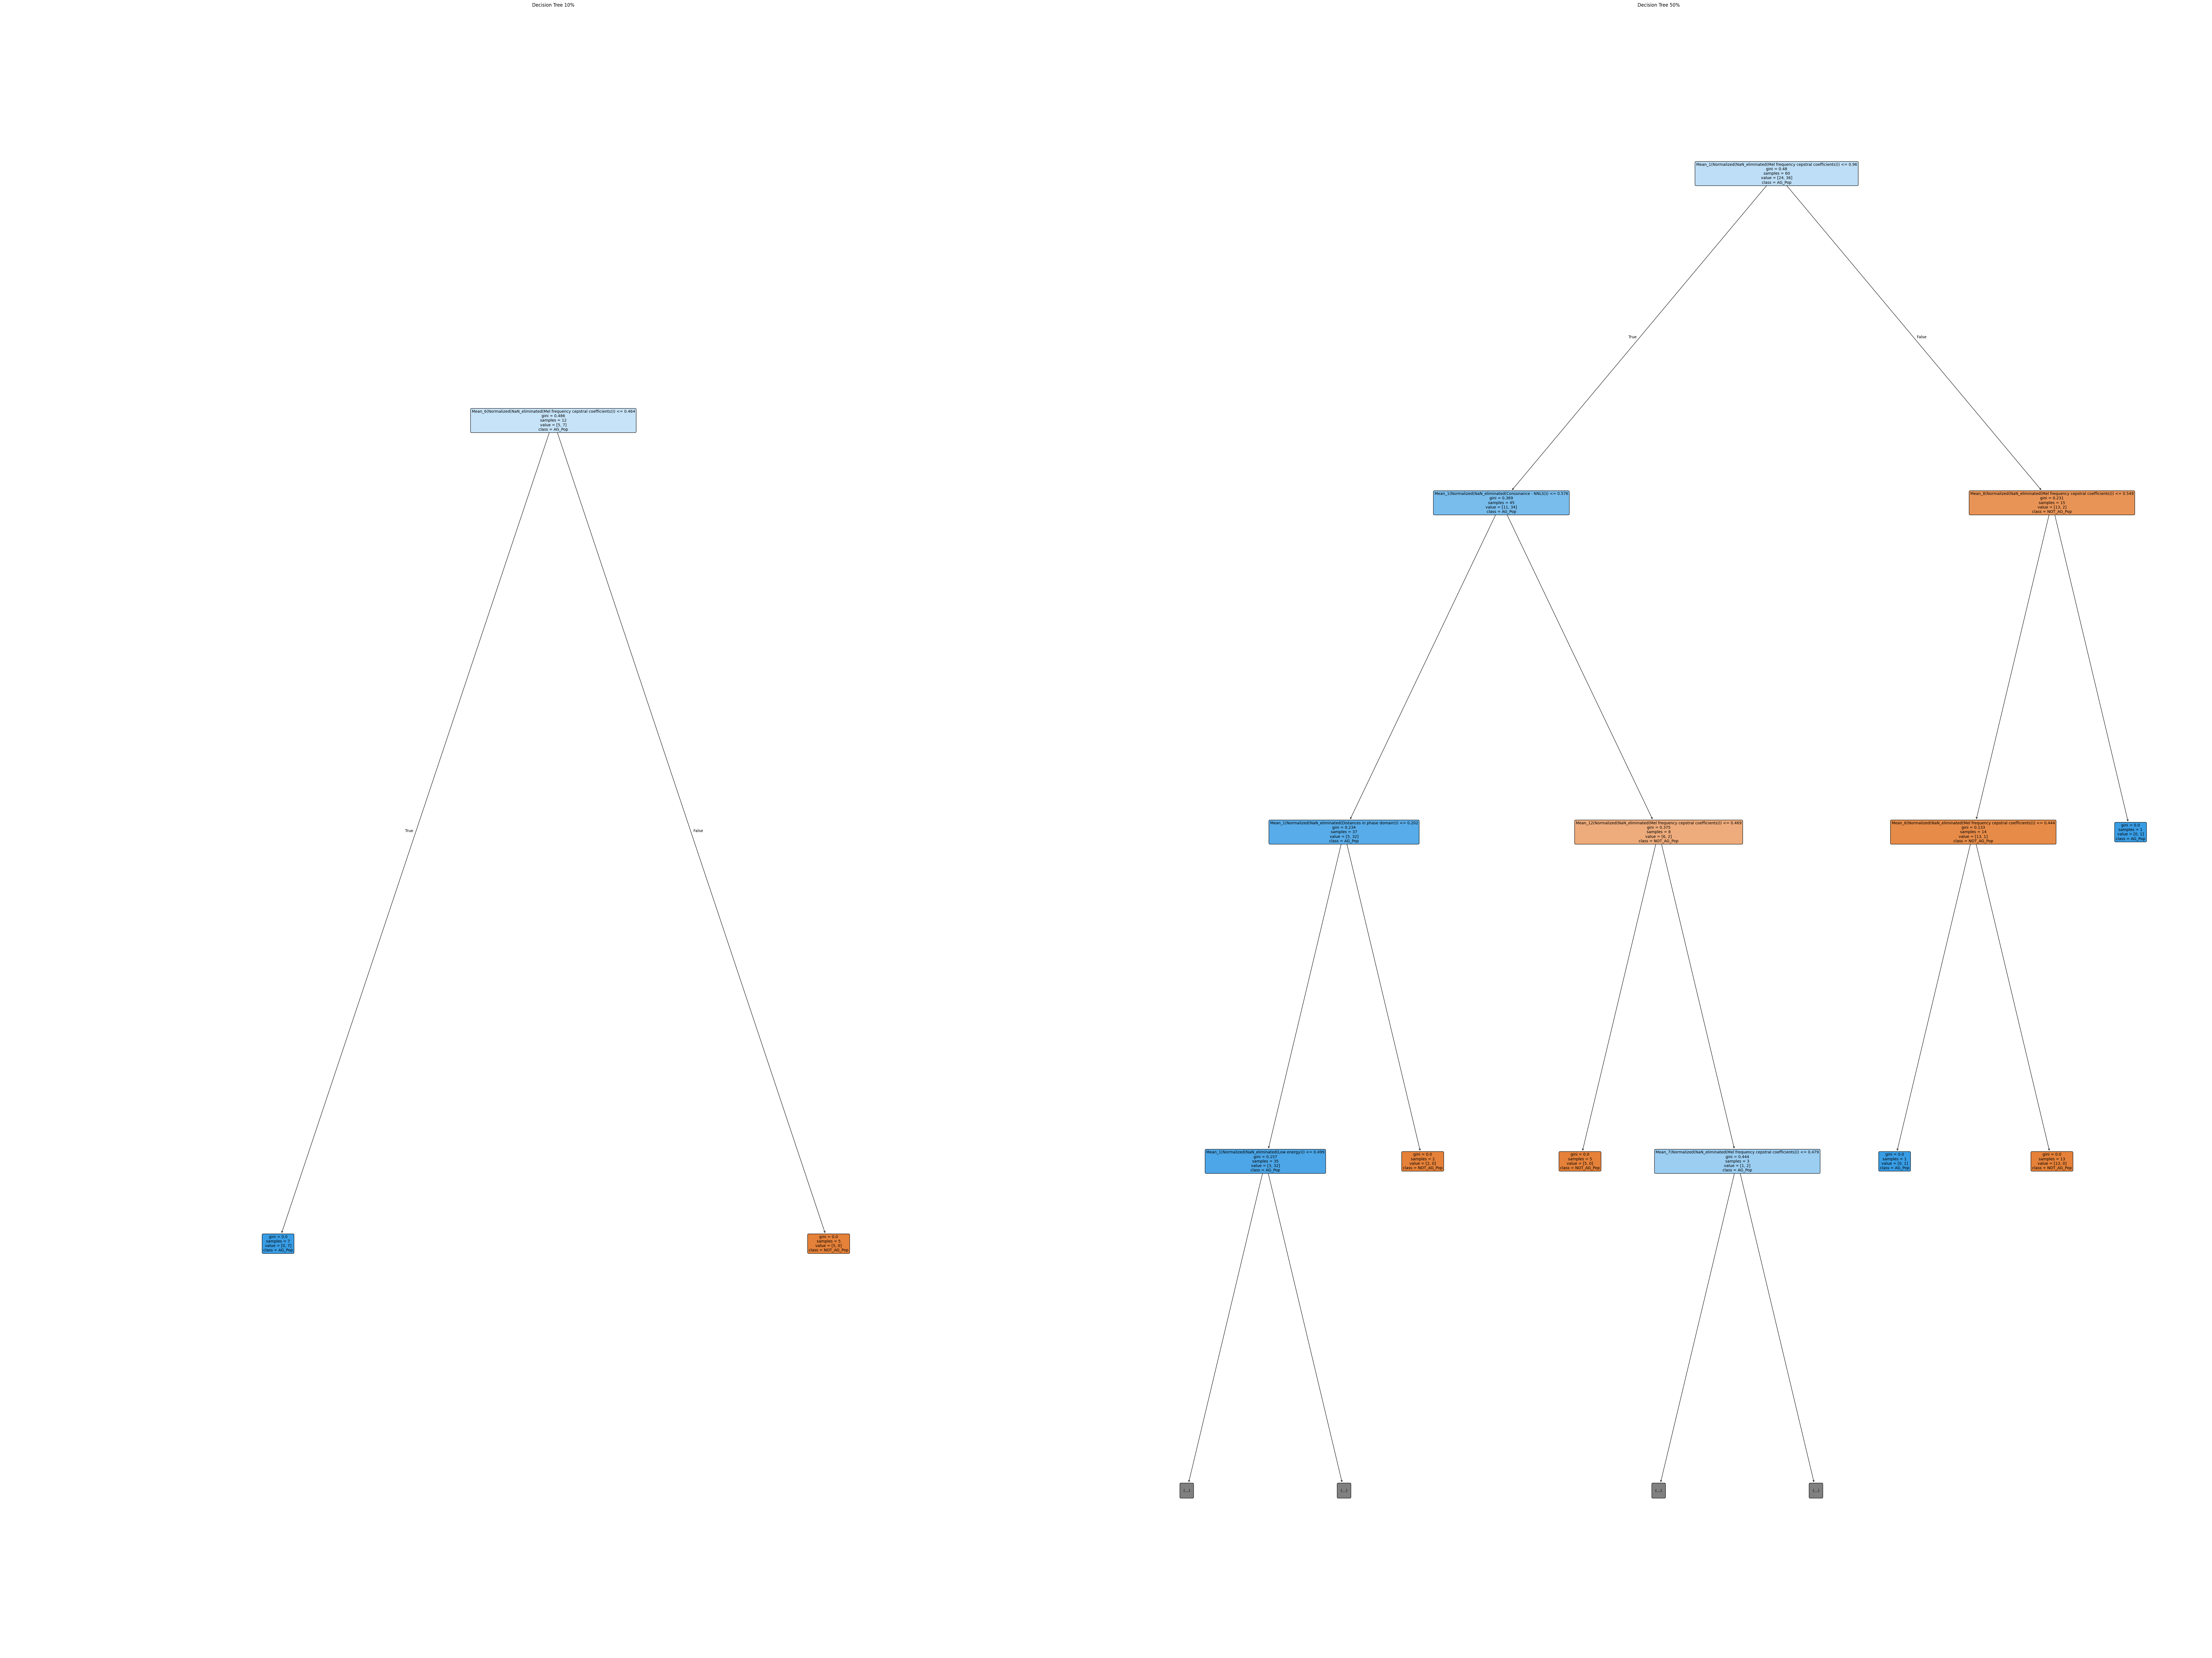

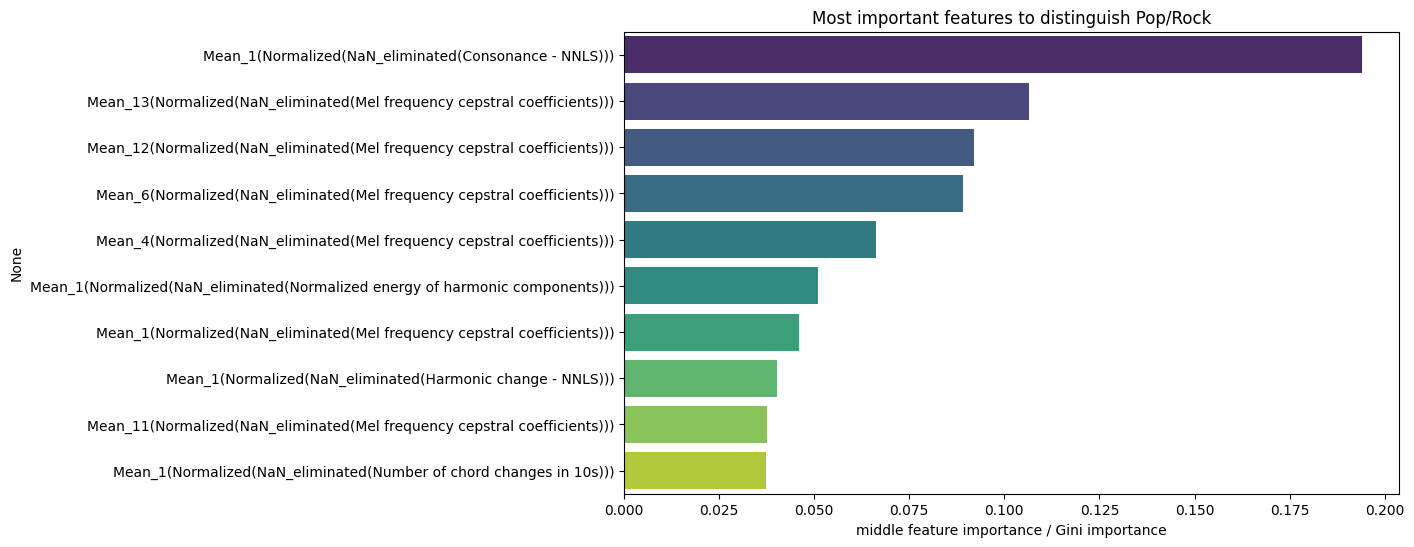

In [60]:

# choose the 10 and 50 percent tree with seed 0
clf_low_data = all_trees_dict["10_0"]
clf_high_data = all_trees_dict["50_0"]

# get feature and class names for labels
feature_names = train_df.drop(columns=[target_column]).columns.tolist()
class_names = [str(c) for c in train_df[target_column].unique()]

plt.figure(figsize=(80, 60))

plt.subplot(1, 2, 1)
tree.plot_tree(clf_low_data, feature_names=feature_names, class_names=class_names,filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Decision Tree 10%")

plt.subplot(1, 2, 2)
tree.plot_tree(clf_high_data, feature_names=feature_names, class_names=class_names,filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Decision Tree 50%")

plt.tight_layout()


importances_df = pd.DataFrame(index=feature_names)

#collect importance from all trained trees
for name, clf in all_trees_dict.items():
    importances_df[name] = clf.feature_importances_

#calculate mean
importances_df['mean_importance'] = importances_df.mean(axis=1)
importances_df = importances_df.sort_values('mean_importance', ascending=False)


print("Top 5 most common features")
print(importances_df['mean_importance'].head(5))

#plot importances of features
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_df['mean_importance'].head(10), 
            y=importances_df.head(10).index, 
            hue=importances_df.head(10).index,
            palette='viridis',
            legend=False)
plt.title("Most important features to distinguish Pop/Rock")
plt.xlabel("middle feature importance / Gini importance")
